In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Change matplot style
plt.style.use("ggplot")

In [3]:
df = pd.read_csv(r"C:\Users\Judson\Desktop\IBM SkillsBuild\PYTHON PROJECTS\PROJECT 2\email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [5]:
df.tail(1)

,Category,Message
5572,"{""mode"":""full""",isActive:false}


In [6]:
df["Category"].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [7]:
# Remove the last row from the data
df = df.iloc[:-1]

In [8]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [10]:
df.shape

(5572, 2)

In [11]:
df.dtypes

Category    object
Message     object
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [13]:
#Check missing values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [14]:
# Chech duplicated values

df.duplicated().sum()

np.int64(415)

In [15]:
#Check the percentage of duplicated values

df.duplicated().sum() / df.shape[0]

np.float64(0.07447954055994258)

In [16]:
#Drop duplicates

df.drop_duplicates(inplace = True)
df

C:\Users\Judson\AppData\Local\Temp\ipykernel_28952\579864699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace = True)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [17]:
''' 
We see that ham is in greater number so we need to take in consideration 
our model might predict based on the higher frequency of ham
so certain techniques must be used to equate the weights of both categories
'''
df["Category"].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [18]:
# Check the percenatage when normalized

df["Category"].value_counts(normalize=True) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

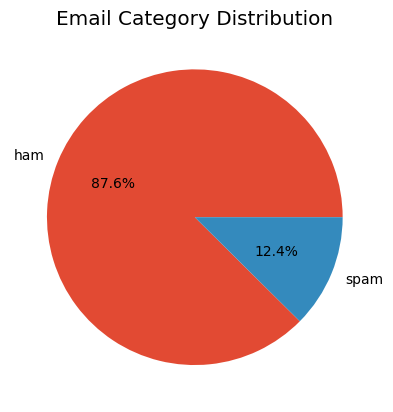

In [19]:
df["Category"].value_counts().plot(
    kind = "pie",
    autopct = "%1.1f%%"
    )

plt.ylabel("")
plt.title("Email Category Distribution")
plt.show()

In [20]:
df["Message_Length"] = df["Message"].apply(len)
df.head()

C:\Users\Judson\AppData\Local\Temp\ipykernel_28952\3451340940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Message_Length"] = df["Message"].apply(len)


,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

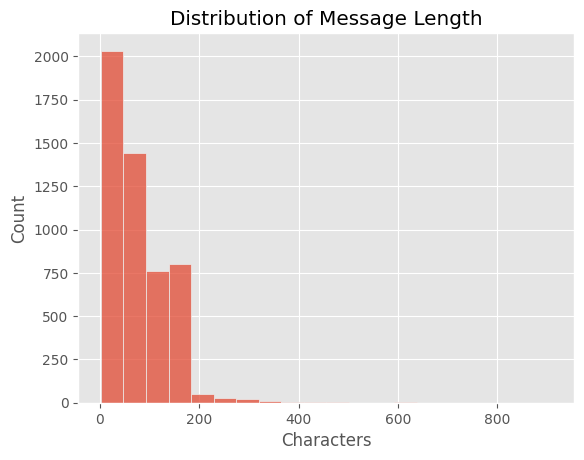

In [22]:
sns.histplot(df["Message_Length"], bins = 20)
plt.title("Distribution of Message Length")
plt.xlabel("Characters")
plt.show()

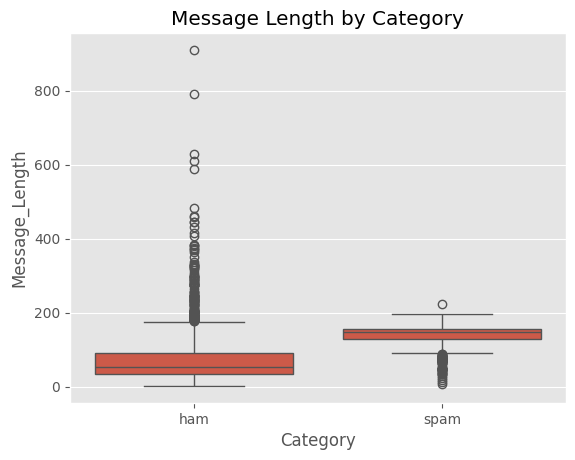

In [23]:
sns.boxplot(
    data = df,
    x = "Category",
    y = "Message_Length"
)

plt.title("Message Length by Category")
plt.show()


In [24]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

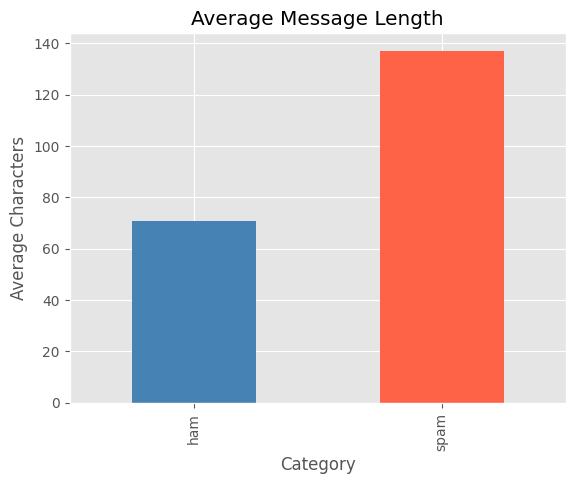

In [25]:
df.groupby("Category")["Message_Length"].mean().plot(
    kind = "bar",
    color = ["steelblue","tomato"]
    
)

plt.ylabel("Average Characters")
plt.title("Average Message Length")

plt.show()

# WORD COUNT

In [26]:
df["Word_Count"] = df["Message"].apply(lambda x: len(x.split()))

C:\Users\Judson\AppData\Local\Temp\ipykernel_28952\4094542584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Word_Count"] = df["Message"].apply(lambda x: len(x.split()))


In [27]:
df.head()

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


<Axes: xlabel='Word_Count', ylabel='Count'>

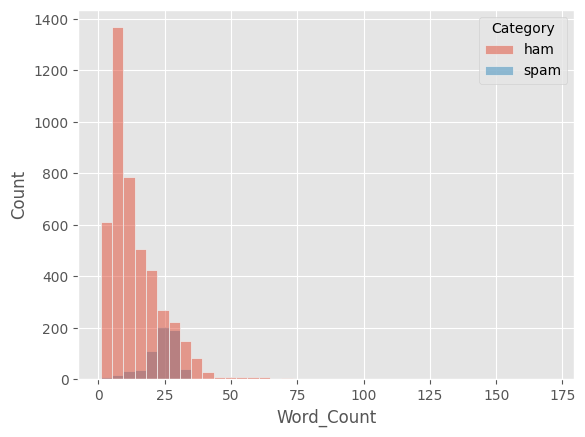

In [28]:
sns.histplot(
    data = df,
    x = "Word_Count",
    hue = "Category",
    bins = 40
)

In [29]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [30]:
# Get the shortest messages
df.nsmallest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [31]:
df.nlargest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


In [32]:
df[df["Category"] == "spam"].sample(5)   

,Category,Message,Message_Length,Word_Count
5250,spam,Urgent! Please call 09061213237 from a landlin...,126,23
4298,spam,thesmszone.com lets you send free anonymous an...,138,20
4506,spam,Mobile Club: Choose any of the top quality ite...,73,13
5501,spam,PRIVATE! Your 2003 Account Statement for 07808...,148,21
2119,spam,U can WIN £100 of Music Gift Vouchers every we...,159,24


In [33]:
df[df["Category"] == "ham"].sample(5) 

,Category,Message,Message_Length,Word_Count
2645,ham,My friends use to call the same.,32,7
2599,ham,Okie... Thanx...,16,2
2008,ham,Hi here. have birth at on the to at 8lb 7oz....,81,16
5519,ham,Can you pls send me that company name. In saib...,56,11
4241,ham,The LAY MAN! Just to let you know you are miss...,155,32


In [34]:
# Set Category to numbers
df["Category"] = df["Category"].map(
    {'ham' : 0,
     'spam' : 1
    }

)

C:\Users\Judson\AppData\Local\Temp\ipykernel_28952\812505297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Category"] = df["Category"].map(


In [35]:
df.head()

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [36]:
import warnings
warnings.filterwarnings("ignore")

# SPLITTING AND TRAINING

In [37]:
from sklearn.model_selection import train_test_split


In [38]:
X = df["Message"]

In [39]:
y = df["Category"]

In [40]:
# 20% testing, 80% training
x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y)

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
 
tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features = 5000,
    ngram_range = (1,2)
)

In [42]:
x_train_tfidf = tfidf.fit_transform(x_train)

In [43]:
x_test_tfidf = tfidf.transform(x_test)

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

In [45]:
models = {
    "Naive Bayes": (
        MultinomialNB(),
        {
            "alpha": [0.1, 0.5, 1, 2, 5]
        }
    ),

    "Logistic Regression": (
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100]
        }
    ),

    "Linear SVM": (
        LinearSVC(
            class_weight="balanced"
        ),
        {
            "C": [0.01, 0.1, 1, 10]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced"
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    ),

    "Decision Tree": (
        DecisionTreeClassifier(
            class_weight="balanced"
        ),
        {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 9]
        }
    )
}

In [48]:
results = []
best_models = {}

for name, (model, params) in models.items():

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=10,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        random_state=42
    )

    search.fit(x_train_tfidf, y_train)

    best_model = search.best_estimator_
    best_models[name] = best_model

    predictions = best_model.predict(x_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    try:
        auc = roc_auc_score(
            y_test,
            best_model.decision_function(x_test_tfidf)
        )
    except AttributeError:
        try:
            auc = roc_auc_score(
                y_test,
                best_model.predict_proba(x_test_tfidf)[:, 1]
            )
        except AttributeError:
            auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc,
        "Best Params": search.best_params_
    })

In [49]:
results

[{'Model': 'Naive Bayes',
  'Accuracy': 0.9864341085271318,
  'Precision': 0.9523809523809523,
  'Recall': 0.9375,
  'F1 Score': 0.9448818897637795,
  'ROC AUC': 0.9901133849557522,
  'Best Params': {'alpha': 0.1}},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.9835271317829457,
  'Precision': 0.9302325581395349,
  'Recall': 0.9375,
  'F1 Score': 0.933852140077821,
  'ROC AUC': 0.9893442339601769,
  'Best Params': {'C': 100}},
 {'Model': 'Linear SVM',
  'Accuracy': 0.9835271317829457,
  'Precision': 0.937007874015748,
  'Recall': 0.9296875,
  'F1 Score': 0.9333333333333333,
  'ROC AUC': 0.9910467367256637,
  'Best Params': {'C': 1}},
 {'Model': 'Random Forest',
  'Accuracy': 0.9689922480620154,
  'Precision': 0.8478260869565217,
  'Recall': 0.9140625,
  'F1 Score': 0.8796992481203008,
  'ROC AUC': 0.984314504977876,
  'Best Params': {'n_estimators': 100,
   'min_samples_split': 10,
   'max_depth': None}},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9563953488372093,
  'Precision': 

In [50]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by = "F1 Score",
    ascending = False
)

In [51]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.986434,0.952381,0.937500,0.944882,0.990113,{'alpha': 0.1}
1,Logistic Regression,0.983527,0.930233,0.937500,0.933852,0.989344,{'C': 100}
2,Linear SVM,0.983527,0.937008,0.929688,0.933333,0.991047,{'C': 1}
3,Random Forest,0.968992,0.847826,0.914062,0.879699,0.984315,"{'n_estimators': 100, 'min_samples_split': 10,..."
5,Gradient Boosting,0.967054,0.919643,0.804688,0.858333,0.980153,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
4,Decision Tree,0.956395,0.812030,0.843750,0.827586,0.892436,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.931202,1.000000,0.445312,0.616216,0.811804,{'n_neighbors': 3}


In [52]:
results_df.style.background_gradient(
    cmap = "Greens",
    subset = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.986434,0.952381,0.937500,0.944882,0.990113,{'alpha': 0.1}
1,Logistic Regression,0.983527,0.930233,0.937500,0.933852,0.989344,{'C': 100}
2,Linear SVM,0.983527,0.937008,0.929688,0.933333,0.991047,{'C': 1}
3,Random Forest,0.968992,0.847826,0.914062,0.879699,0.984315,"{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None}"
5,Gradient Boosting,0.967054,0.919643,0.804688,0.858333,0.980153,"{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}"
4,Decision Tree,0.956395,0.812030,0.843750,0.827586,0.892436,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.931202,1.000000,0.445312,0.616216,0.811804,{'n_neighbors': 3}


In [53]:
best_model_name = results_df.iloc[0]["Model"]

In [54]:
best_model_name


'Naive Bayes'

In [55]:
best_model = best_models[best_model_name]
best_model

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3612., 513.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.08]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[0. ,0. ,0. ,...,0. ,0.38,0.38], [0.9 ,3.4 ,1.04,...,0.33,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-11.4 ,-11.4 ,-11.4 ,...,-11.4 , -9.83, -9.83], [ -7.86, -6.61, -7.73,..., -8.71,-10.16,-10.16]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


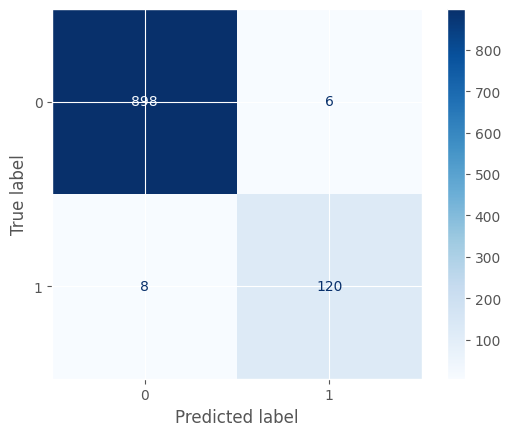

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    x_test_tfidf,
    y_test,
    cmap = "Blues"
)

plt.show()

In [57]:
emails = [
    "Congratulations! You won a free iPhone. Click here now",
    "Hey, are we still meeting tomorrow at 10 AM ?",
    "URGENT! Claim your $1000 Walmart gift card today."
]

emails_vectorized = tfidf.transform(emails)

predictions = best_model.predict(emails_vectorized)

for email, prediction in zip(emails, predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print(label, ":", email)

Spam : Congratulations! You won a free iPhone. Click here now
Ham : Hey, are we still meeting tomorrow at 10 AM ?
Spam : URGENT! Claim your $1000 Walmart gift card today.


In [58]:
import pickle

with open("Spam_classifier.pkl", "wb") as file:
    pickle.dump(best_model,file)

In [59]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)
print("Success")

Success
